In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruchikakumbhar/calories-burnt-prediction")

print("Path to dataset files:", path)

100%|██████████| 236k/236k [00:00<00:00, 38.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ruchikakumbhar/calories-burnt-prediction/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
print(os.listdir(path))

['calories.csv']


In [ ]:
# Based on the dataset name 'calories-burnt-prediction', 'calories.csv' is a likely candidate for the main data file.
# If the previous cell's output shows a different main CSV file, this path might need adjustment.
data_file_path = os.path.join(path, 'calories.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [ ]:
df.shape

(15000, 9)

### Distribution of Numerical Features

Let's visualize the distribution of each numerical feature using histograms to understand their spread, central tendency, and identify any potential outliers or skewedness.

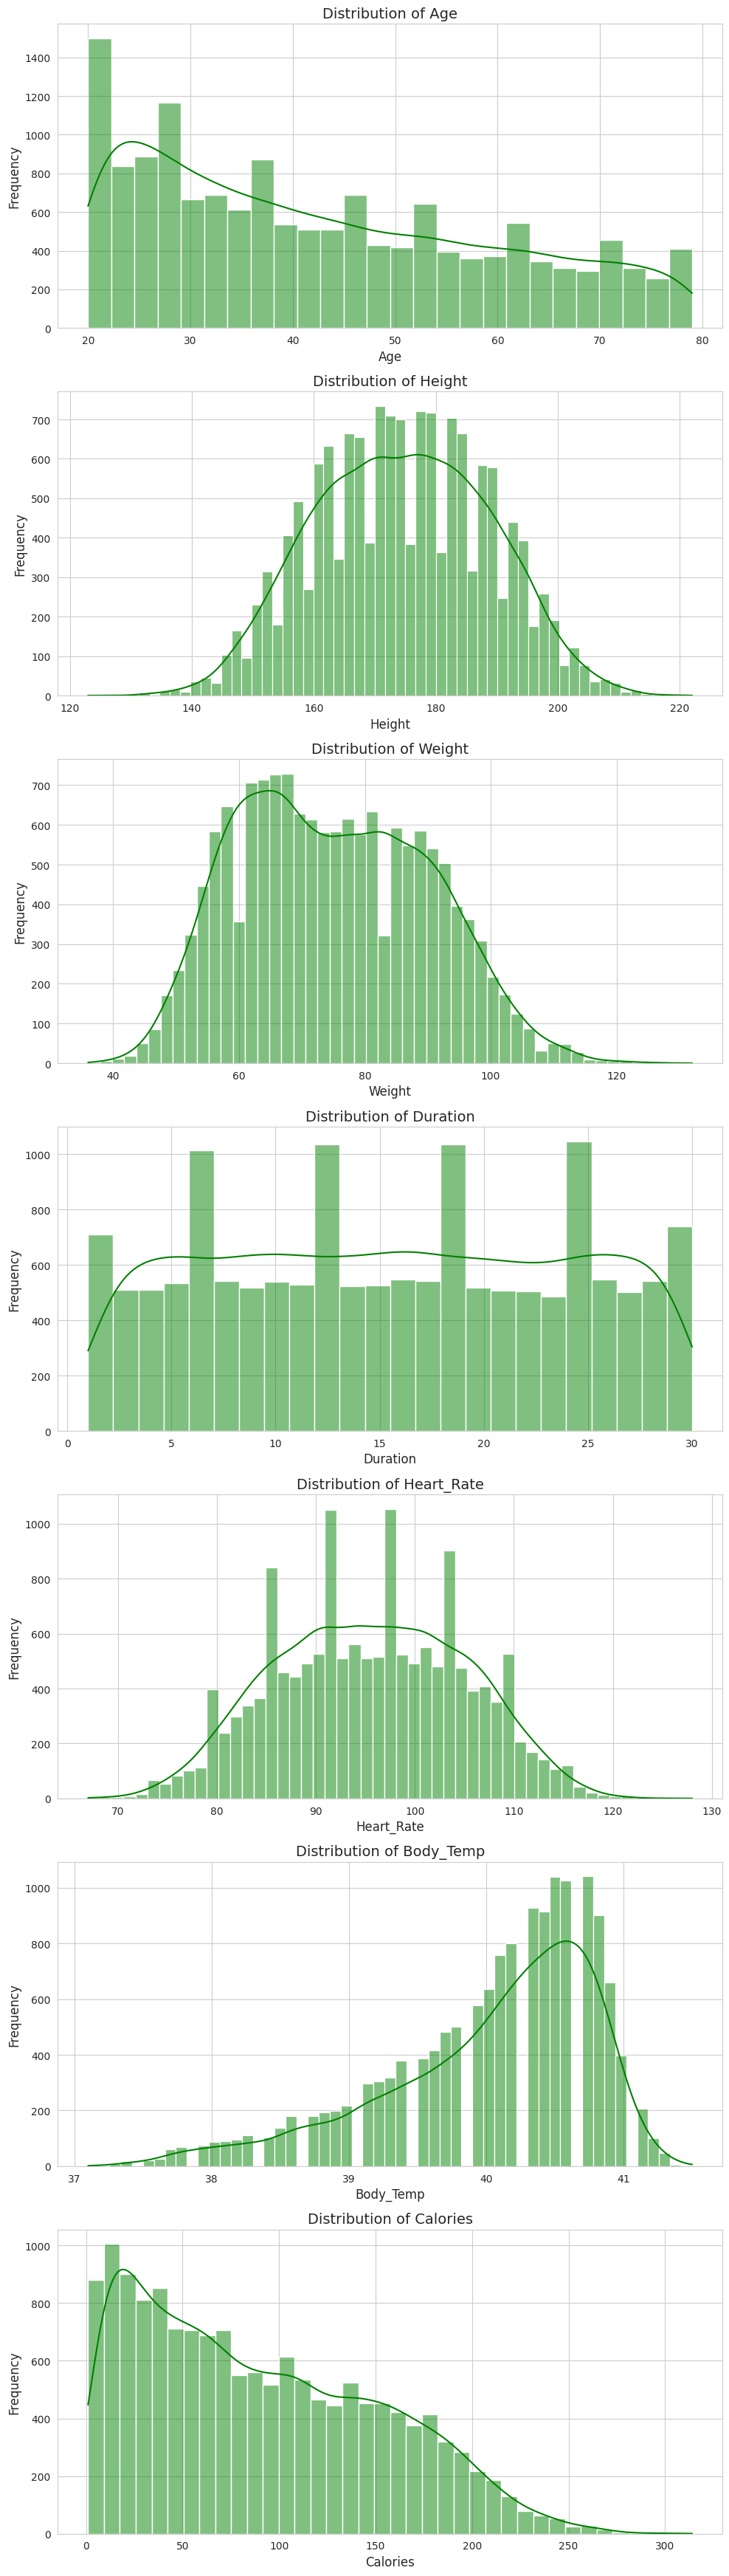

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# List of numerical columns to plot
numerical_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

# Create subplots for each numerical feature
fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='green')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

Let's examine the distribution of the categorical feature 'Gender' to see the balance of categories.

/tmp/ipykernel_1141/772880153.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis')


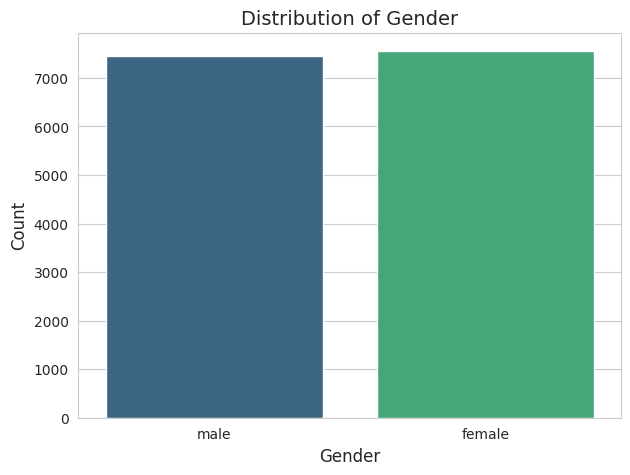

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for 'Gender'
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Distribution of Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Relationship between Duration and Calories

Let's visualize the relationship between 'Duration' (exercise duration) and 'Calories' (calories burned) using a scatter plot. We expect to see a positive correlation here.

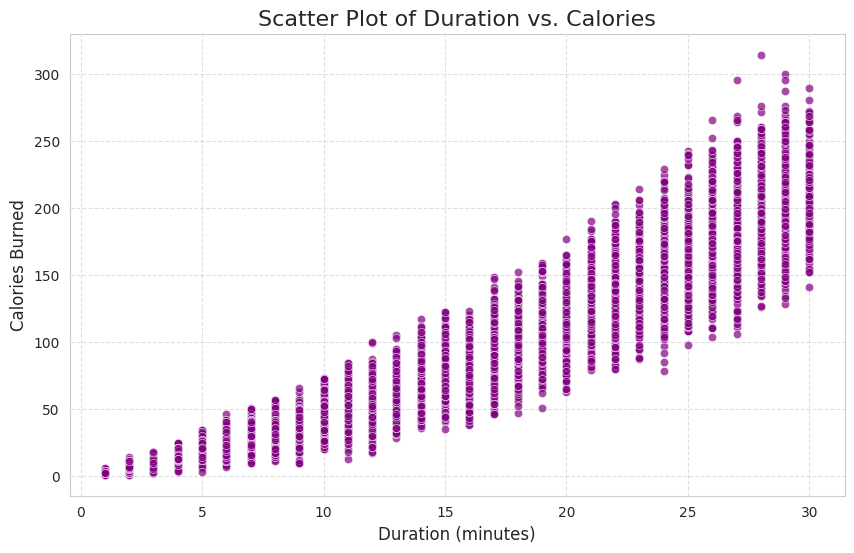

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration', y='Calories', alpha=0.7, color='purple')
plt.title('Scatter Plot of Duration vs. Calories', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Calories Burned', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Relationship between Gender and Calories

To understand how 'Gender' might influence 'Calories' burned, let's use a box plot. This will allow us to compare the median, quartiles, and potential outliers for calories burned across different genders.

/tmp/ipykernel_1141/1277206258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Calories', palette='viridis')


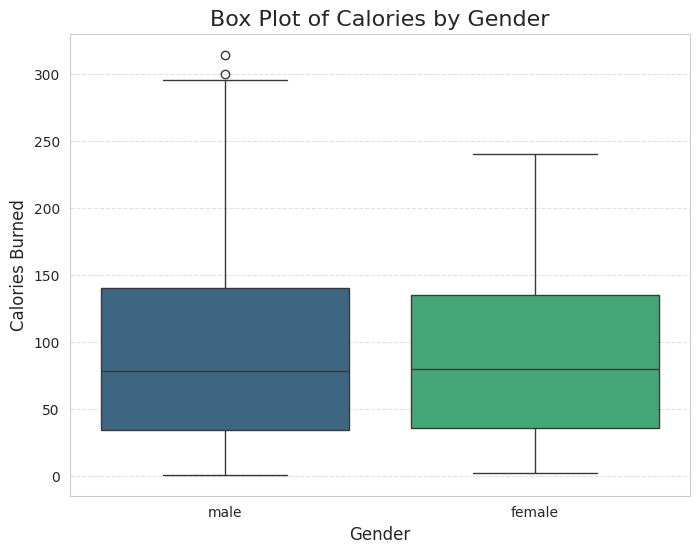

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Calories', palette='viridis')
plt.title('Box Plot of Calories by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Calories Burned', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df.isnull()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False


In [ ]:
df['Gender']=df['Gender'].map({'male':0,'female':1})

In [ ]:
df.skew()

,0
User_ID,0.004788
Gender,-0.014135
Age,0.473383
Height,-0.006190
Weight,0.226725
Duration,0.004751
Heart_Rate,-0.010704
Body_Temp,-0.994382
Calories,0.505371


<Axes: xlabel='Calories', ylabel='Count'>

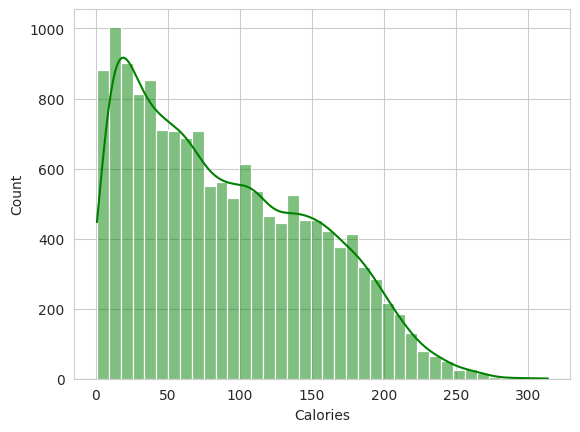

In [ ]:
import seaborn as sns
sns.histplot(df['Calories'],kde=True,color='green')

In [ ]:
#standard scaler
# distance based algorithm
x=df.drop(columns=['Calories','User_ID'],axis=1)
y=df['Calories']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
#Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
Param_Grid={
    'max_depth':[2,5,10,None],
    'n_estimators':[100,200,300],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
Randomized = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=Param_Grid,
    n_iter=10,
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [ ]:
Randomized.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [2, 5, 10, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=1)

In [ ]:
Randomized.best_score_

np.float64(0.9968667643441973)

In [ ]:
# Building random forest model

RFmodel=RandomForestRegressor(n_estimators=300,max_depth=10)

In [ ]:
#1 Train
RFmodel.fit(x_train,y_train)



RandomForestRegressor(max_depth=10, n_estimators=300)

In [ ]:
#2 prediction
y_pred=RFmodel.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
#testing
r2_score(y_test,y_pred)

0.997224546838392

In [ ]:
r2_score(y_train,RFmodel.predict(x_train))

0.9984937023407842

In [ ]:
mean_absolute_error(y_test,y_pred)

2.2243628758458405

In [ ]:
import joblib
joblib.dump(r2_score,'Random_forest.pkl')

['Random_forest.pkl']